In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
# from opendrift.readers import reader_netCDF_CF_generic
# from opendrift.readers import reader_global_landmask
# import opendrift.readers as readers
# from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [2]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'

path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [3]:
model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)

In [4]:
model_uv.time

<xarray.DataArray 'time' (time: 9119)>
array(['2011-11-01T00:00:00.000000000', '2011-11-01T01:00:00.000000000',
       '2011-11-01T02:00:00.000000000', ..., '2012-11-14T21:00:00.000000000',
       '2012-11-14T22:00:00.000000000', '2012-11-14T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
    k        int64 0

In [5]:
f = tools.f_grid(model_uv,'lat')

In [6]:
# for i in tqdm(range(0,len(model_uv.time))):
#     #field_v = tools.calculate_vorticity(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
#     #field_d = tools.calculate_divergence(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
#     field_str = tools.calculate_strain_rate(model_uv['u'].isel(time=i),model_uv['v'].isel(time=i),model_uv['DXC'],model_uv['DYC'],model_uv['RAZ'],f)
#     time = [np.array(model_uv.isel(time = i).time)]
#     i0 = model_uv.i[:-1]
#     j0 = model_uv.j[:-1]
#     #field_v = np.reshape(field_v, (1,np.shape(field_v)[0],np.shape(field_v)[1]))
#     #field_d = np.reshape(field_d, (1,np.shape(field_d)[0],np.shape(field_d)[1]))
#     field_str = np.reshape(field_str, (1,np.shape(field_str)[0],np.shape(field_str)[1]))
#     #vorticity = xr.DataArray(field_v, coords = [time,i0,j0], dims = ['time','i','j'], name ='vorticity')
#     #divergence = xr.DataArray(field_d, coords = [time,i0,j0], dims = ['time','i','j'], name ='divergence')
#     strain_rate = xr.DataArray(field_str, coords = [time,i0,j0], dims = ['time','i','j'], name ='strain_rate')
    
#     #vorticity.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/VORT/'+'vorticity_'+str(i).zfill(4)+'.nc')
#     #divergence.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/DIV/'+'divergence_'+str(i).zfill(4)+'.nc')
#     strain_rate.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/Strain/'+'strain_'+str(i).zfill(4)+'.nc')


In [3]:
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
land_mask = np.array((Land_mask.where(Land_mask<1)+1)[1:,1:])
#lcs_land_nan.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [3]:
vort_files, vort_filepaths = tools.get_data_paths_from_binary(cutout_path,'VORT',file_end='nc')
div_files, div_filepaths =  tools.get_data_paths_from_binary(cutout_path,'DIV', file_end='nc')
vort_div = xr.open_mfdataset(vort_filepaths+div_filepaths)


In [ ]:
strain_files, strain_filepaths = tools.get_data_paths_from_binary(cutout_path,'Strain',file_end='nc')
strain = 

In [4]:
vort_div.to_netcdf(cutout_path+'vorticity_divergence.nc')

In [6]:
lcs_model = xr.open_dataset('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [5]:
vort_div.close()

In [8]:
lcs_land_nan = lcs.where(np.isfinite(lcs_land_mask))
#vort_div_nan = vort_div.where(np.isfinite(lcs_land_mask))

In [6]:
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'
theta_files, theta_filepath = tools.get_data_paths_from_binary(path_tohd,variables[1],file_end='nc')
#salt_files, salt_filepath = tools.get_data_paths_from_binary(path_tohd,variables[2],file_end='nc')
w_files, w_filepath = tools.get_data_paths_from_binary(path_tohd,variables[-3],file_end='nc')

stww = xr.open_mfdataset(theta_filepath+w_filepath)

In [8]:
stw = xr.merge([stw,grid])
stw=stw.set_coords({'XC','YC'})

In [9]:
extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]

stw.sel(XC=slice(extent[0],extent[1]),YC=slice(extent[2],extent[3]))

KeyError: "no index found for coordinate 'XC'"

In [13]:
ds = stw
ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
ds_cut_st = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever
stw.close()

In [15]:
cutout_path = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/'


In [ ]:
st_nan = ds_cut_st.isel(k=0).where(np.isfinite(Land_mask))
st_nan

In [16]:
ds_cut_st.to_netcdf(cutout_path+'salt_temp_w_cape_mend.nc')


In [17]:
salt_temp_w = xr.open_dataset(cutout_path+'salt_temp_w_cape_mend.nc')

<xarray.Dataset>
Dimensions:  (time: 9119, i: 237, j: 216, k: 1)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
  * k        (k) int64 0
Data variables: (12/15)
    Salt     (time, i, j) float32 ...
    Theta    (time, i, j) float32 ...
    W        (time, i, j) float32 ...
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    ...       ...
    Depth    (i, j) float32 ...
    RAC      (i, j) float32 ...
    RAZ      (i, j) float32 ...
    XG       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j, k) float32 ...

In [8]:
lcs_land_mask

array([[ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       ...,
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan]])

## animation

In [4]:
salt_temp_w = xr.open_dataset(cutout_path+'salt_temp_w_cape_mend.nc').isel(k=0,i=slice(0,236),j=slice(215))
vort_div = xr.open_dataset(cutout_path+'vorticity_divergence.nc')
lcs_land_nan = xr.open_dataset('/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')
ridge_points = xr.open_dataset(cutout_path+'ridge_points_repelling_bad.nc')

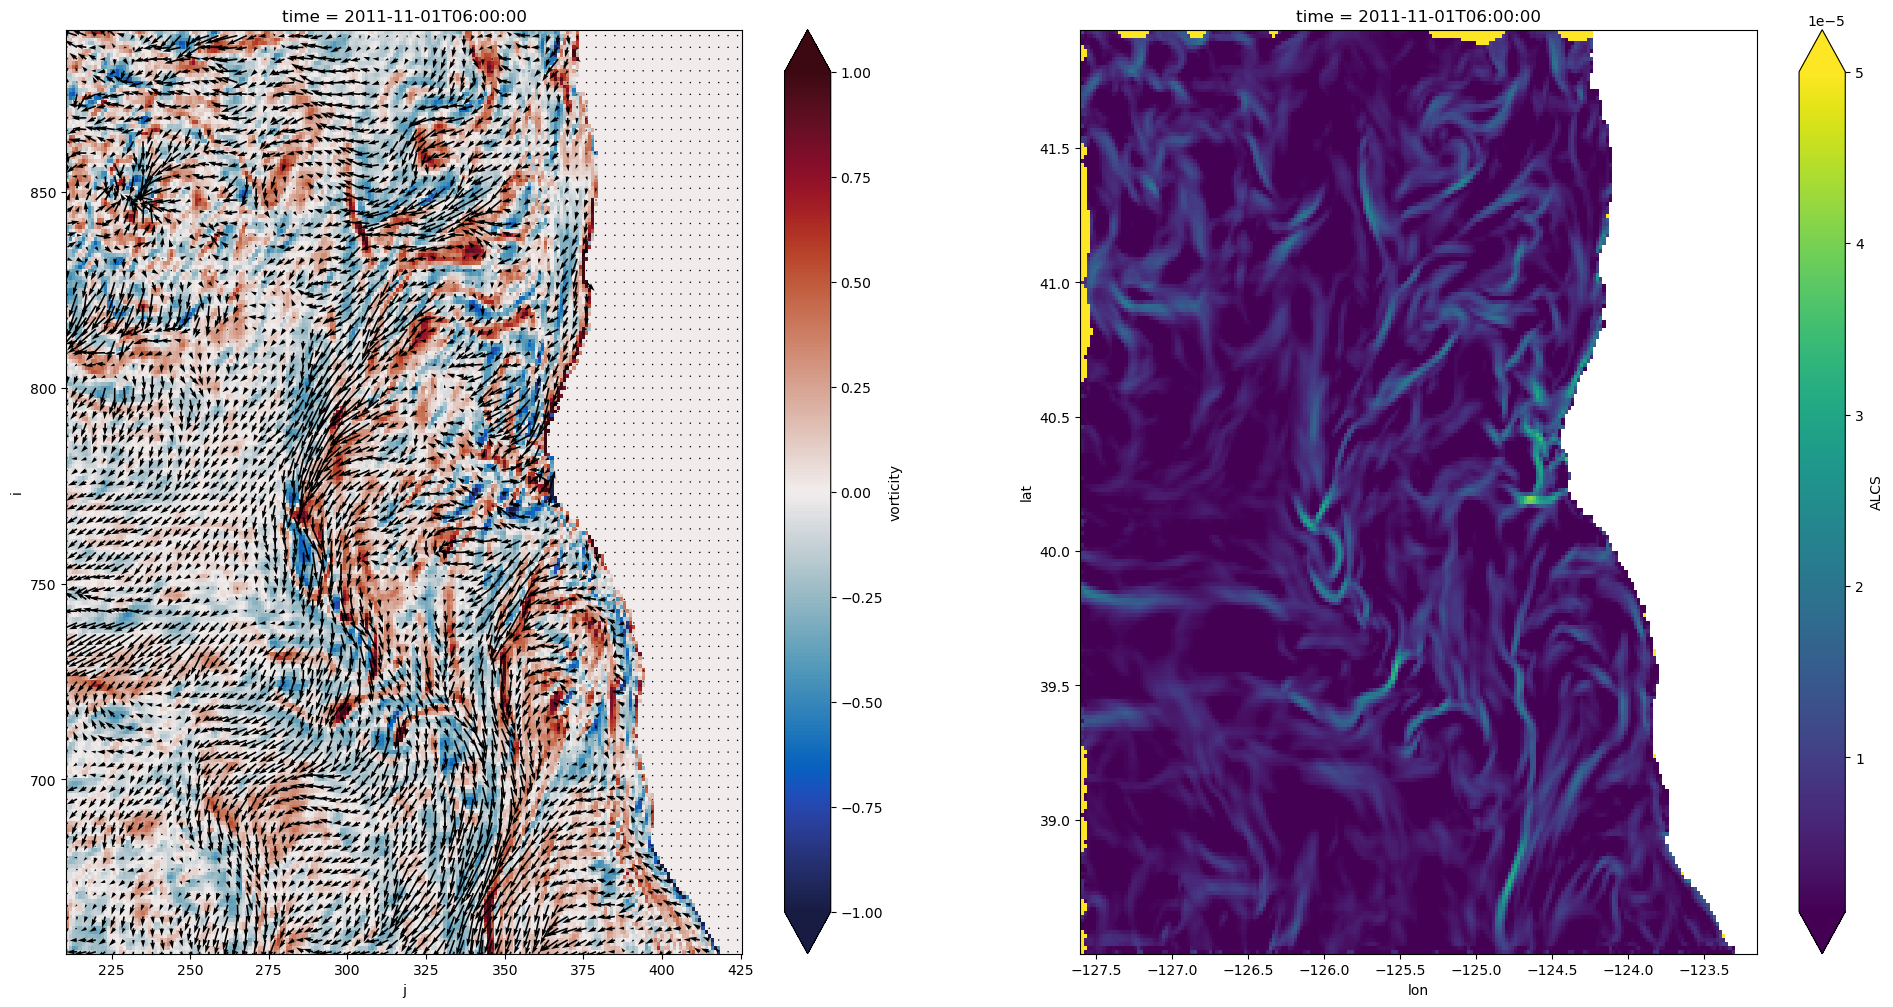

In [31]:
FTLE_threshold = [1e-6,5e-5]
fig,ax = plt.subplots(ncols=2, nrows=1,figsize=(24,12))
lcs_land_nan['ALCS'].isel(time=1).plot(vmin=FTLE_threshold[0],vmax=FTLE_threshold[1],ax=ax[1])
vort_div['vorticity'].isel(time=6).plot(ax=ax[0],vmin=-1,vmax=1,cmap=cmocean.cm.balance)
ax[0].quiver(model_uv.j[::3],model_uv.i[::3],model_uv['u'].isel(time=6)[::3,::3],model_uv['v'].isel(time=6)[::3,::3],scale=15)

In [5]:
# vort_div_nan = vort_div.where(np.isfinite(lcs_land_mask))
# vort_div_nan

In [6]:
# attracting_files, attracting_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/lcs_ridges/','attracting',file_end='nc')
# repelling_files, repelling_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/lcs_ridges/','repelling',file_end='nc')
# ridge_points = xr.open_mfdataset(attracting_filepaths+repelling_filepaths)

In [7]:
# lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures']
# lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
# lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures']
# lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures']
# plt.plot(lon_points_attr,lat_points_attr,'r.',markersize=1)
# plt.plot(lon_points_rep,lat_points_rep,'r.',markersize=1)
#ridge_points.to_netcdf(cutout_path+'ridge_points_repelling_bad.nc')

In [5]:
vort_div.coords['i'] = np.array(lcs_land_nan['lat'])
vort_div.coords['j'] = np.array(lcs_land_nan['lon'])
salt_temp_w.coords['i'] = np.array(lcs_land_nan['lat'])
salt_temp_w.coords['j'] = np.array(lcs_land_nan['lon'])

vort_div = vort_div.rename({'i':'lat','j':'lon'})
salt_temp_w = salt_temp_w.rename({'i':'lat','j':'lon'})
vor_div_lcs = xr.merge([vort_div,lcs_land_nan])
#vor_div_lcs


In [6]:
vor_div_lcs = vor_div_lcs.sel(time=lcs_land_nan.time)
salt_temp_w = salt_temp_w.sel(time=lcs_land_nan.time)

In [7]:
w_filt = xr.open_dataset(path_tohd+'cutouts/w_tidal_removed_lcs_cape_mend.nc')

In [8]:
w_filt.coords['i'] = np.array(lcs_land_nan['lat'])
w_filt.coords['j'] = np.array(lcs_land_nan['lon'])

In [18]:
ridge_points = ridge_points.sel(time='2012-06-21 18')


KeyboardInterrupt



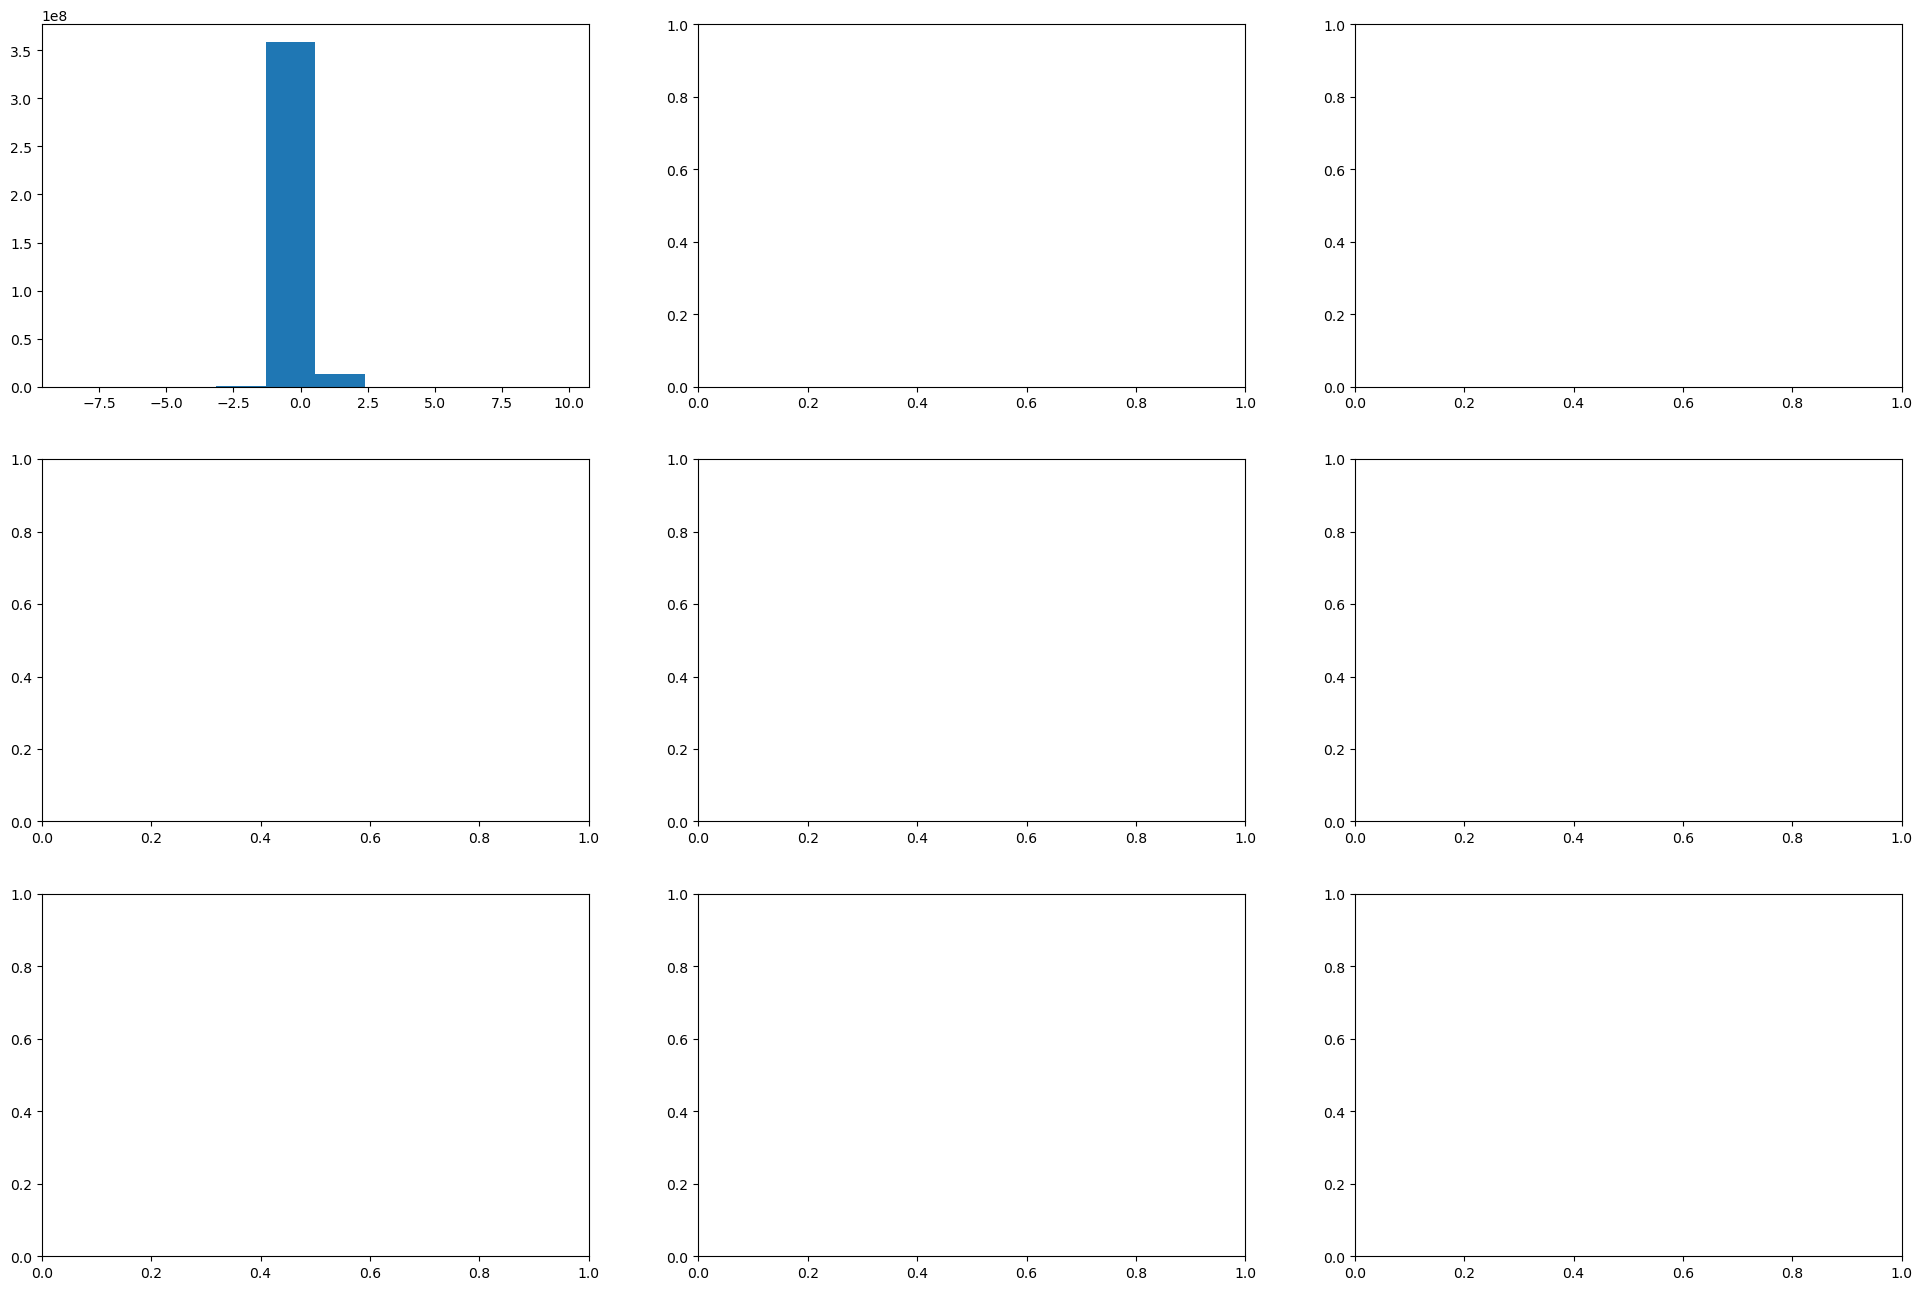

In [6]:
i = 0
FTLE_threshold = [1e-6,5e-5]
FTLE_threshold_r = [-8e-5,0]#repelling
fig,ax = plt.subplots(ncols=3, nrows=3,figsize=(24,16))
vor_div_lcs['divergence'].where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,0])
vor_div_lcs['vorticity'].where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,1])
vor_div_lcs['ALCS'].plot(vmin=FTLE_threshold[0],vmax=FTLE_threshold[1],ax=ax[1,0])
vor_div_lcs['RLCS'].plot(vmin=FTLE_threshold_r[0],vmax=FTLE_threshold_r[1],ax=ax[1,1])
w_filt['W_filtered'].where(np.isfinite(lcs_land_mask)).plot(ax=ax[0,2],cmap=cmocean.cm.balance)
salt_temp_w['Theta'].where(np.isfinite(lcs_land_mask)).plot(ax=ax[1,2],vmin=9,cmap=cmocean.cm.thermal)
salt_temp_w['Salt'].where(np.isfinite(lcs_land_mask)).plot(ax=ax[2,2],vmin=31,cmap=cmocean.cm.haline)
lon_points_attr = ridge_points.isel(lon_lat=0)['attracting_structures']
lat_points_attr = ridge_points.isel(lon_lat=1)['attracting_structures']
lon_points_rep = ridge_points.isel(lon_lat=0)['repelling_structures']
lat_points_rep = ridge_points.isel(lon_lat=1)['repelling_structures']
ax[2,0].plot(lon_points_attr,lat_points_attr,'r.',markersize=1)
ax[2,1].plot(lon_points_rep,lat_points_rep,'r.',markersize=1)
ax[2,0].set_xlabel('lon')
ax[2,0].set_ylabel('lat')
ax[2,1].set_xlabel('lon')
ax[2,1].set_ylabel('lat')
ax[2,1].set_title('extracted repelling ridges')
ax[2,0].set_title('extracted attracting ridges')
plt.tight_layout()
#plt.savefig('./case_study_summer_edd_fil.png')

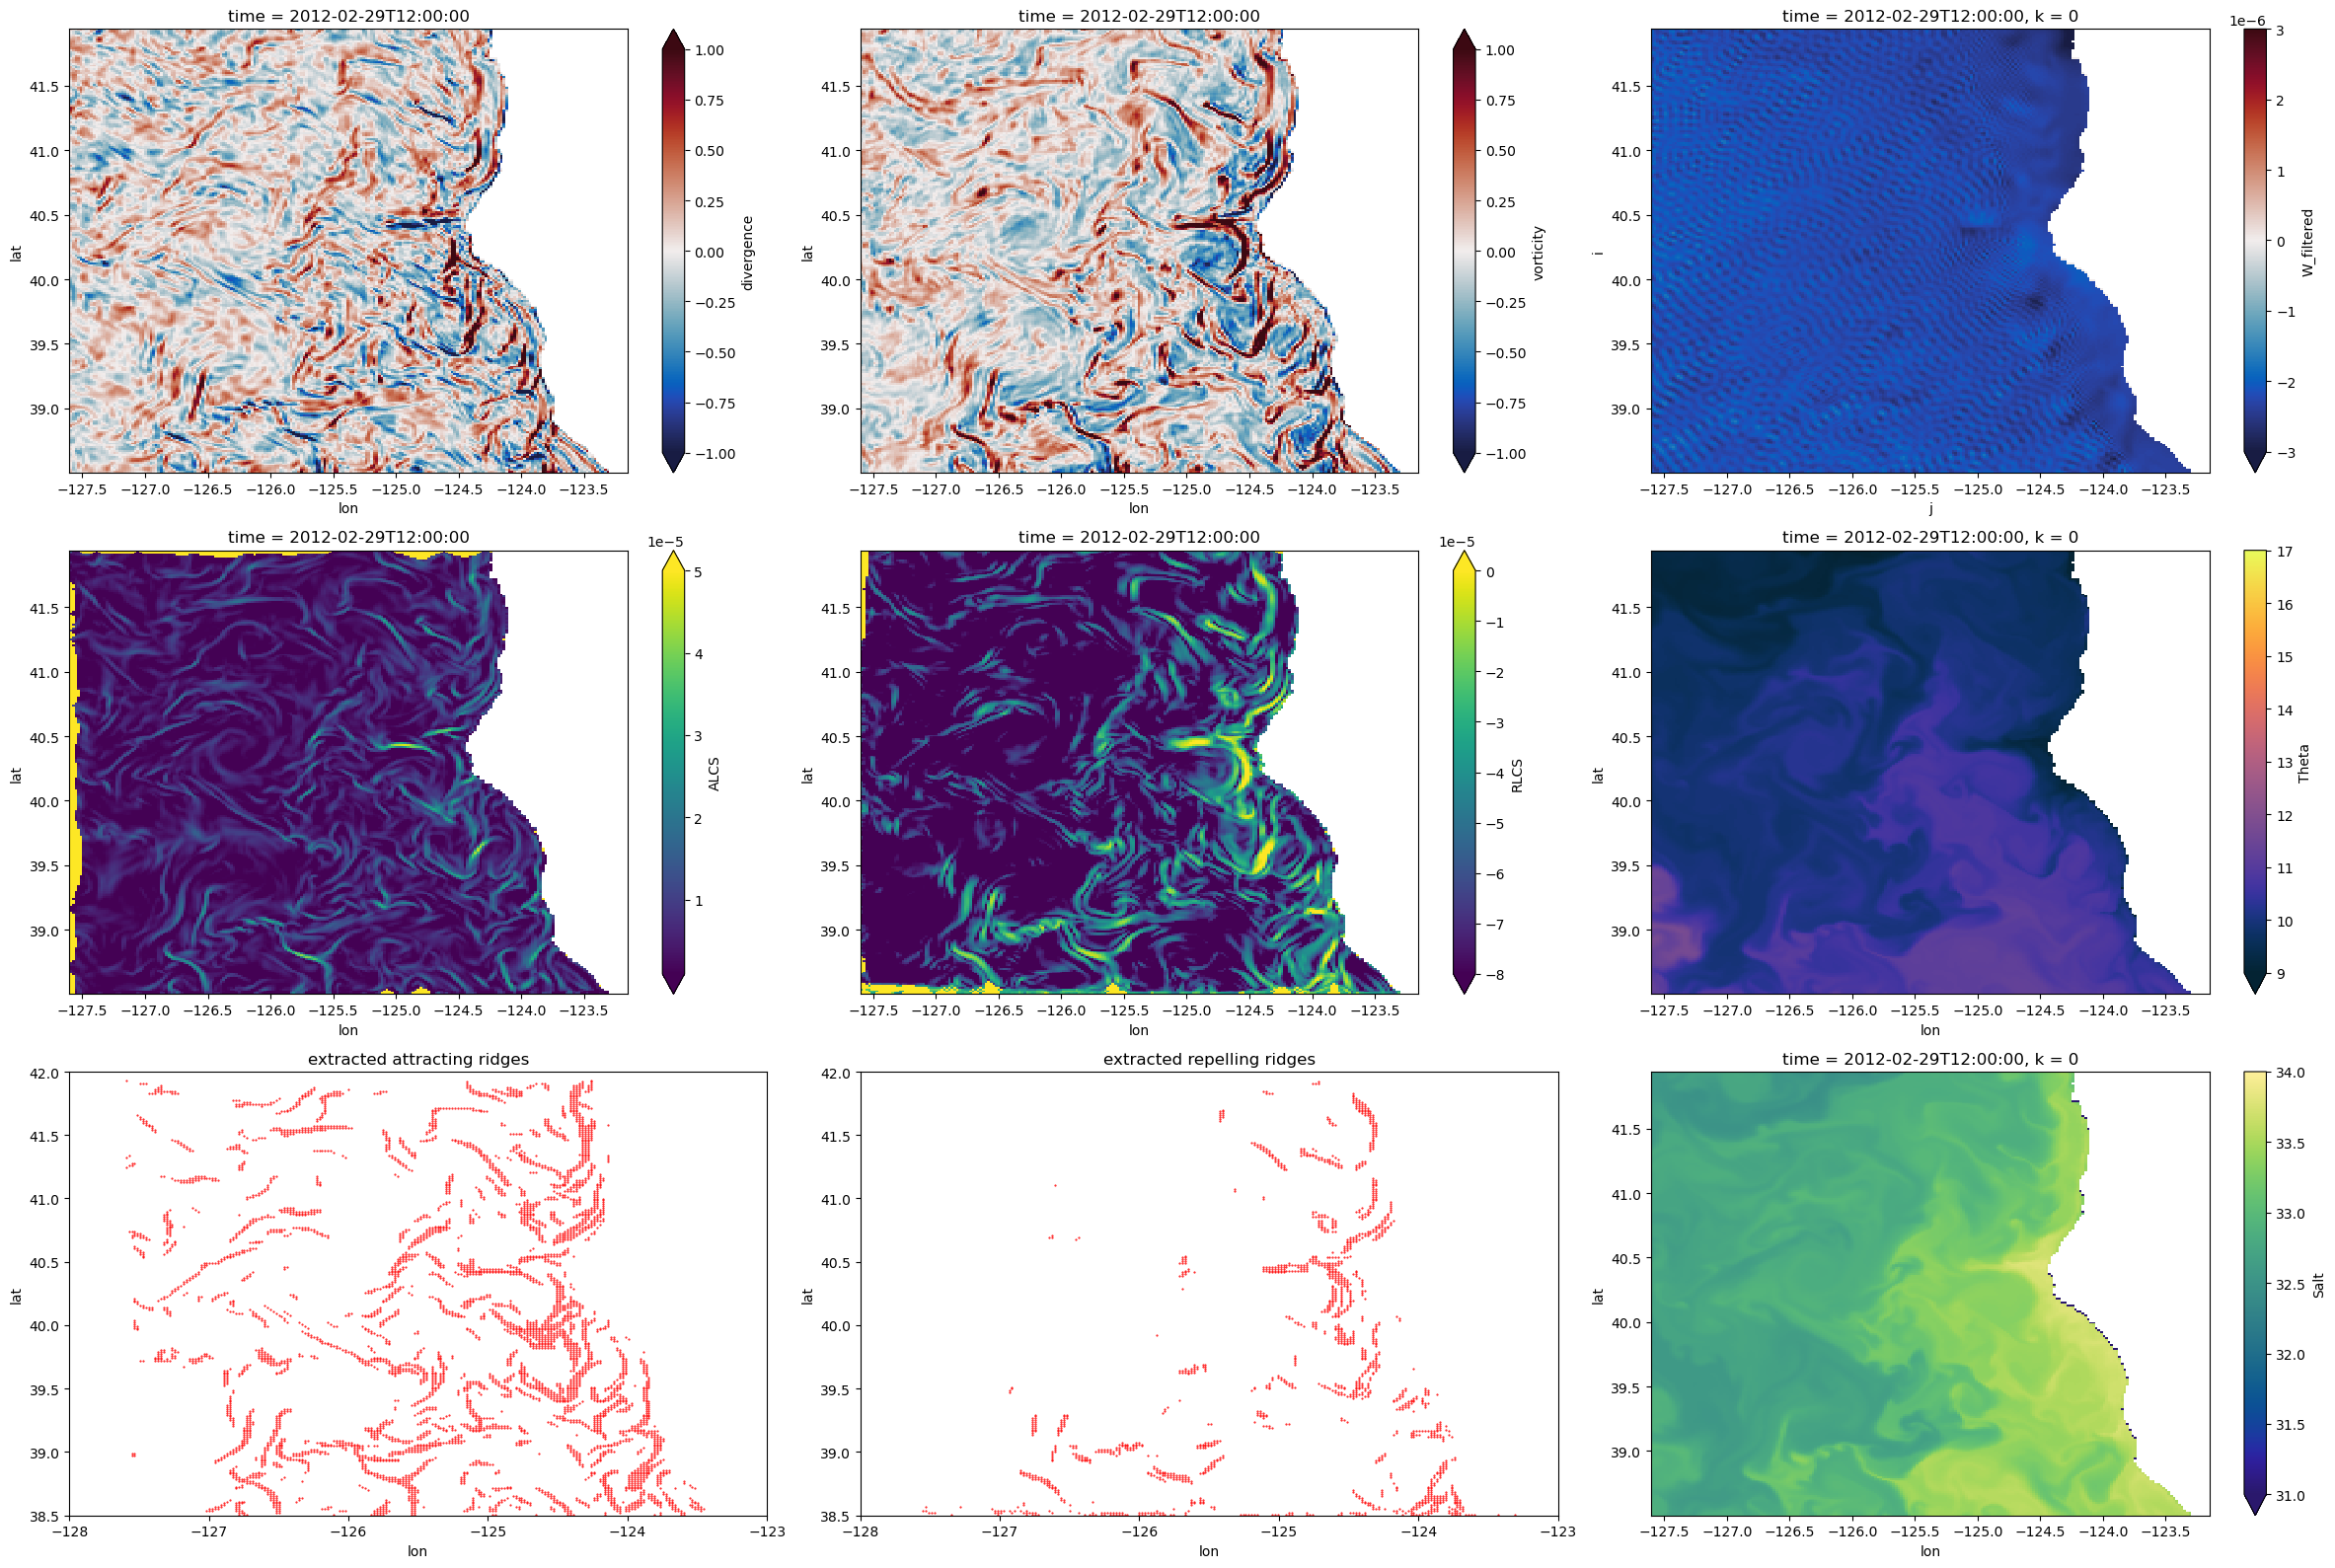

In [24]:
i = 482
FTLE_threshold = [1e-6,5e-5]
FTLE_threshold_r = [-8e-5,0]#repelling
fig,ax = plt.subplots(ncols=3, nrows=3,figsize=(24,16))
vor_div_lcs['divergence'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,0])
vor_div_lcs['vorticity'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,1])
vor_div_lcs['ALCS'].isel(time=i).plot(vmin=FTLE_threshold[0],vmax=FTLE_threshold[1],ax=ax[1,0])
vor_div_lcs['RLCS'].isel(time=i).plot(vmin=FTLE_threshold_r[0],vmax=FTLE_threshold_r[1],ax=ax[1,1])
w_filt['W_filtered'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-3e-6,vmax=3e-6,ax=ax[0,2],cmap=cmocean.cm.balance)
salt_temp_w['Theta'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(ax=ax[1,2],vmin=9,vmax=17,cmap=cmocean.cm.thermal)
salt_temp_w['Salt'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(ax=ax[2,2],vmin=31,vmax=34,cmap=cmocean.cm.haline)
lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures']
lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures']
lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures']
ax[2,0].plot(lon_points_attr,lat_points_attr,'r.',markersize=1)
ax[2,1].plot(lon_points_rep,lat_points_rep,'r.',markersize=1)
ax[2,1].set_xlim([-128,-123])
ax[2,0].set_xlim([-128,-123])
ax[2,1].set_ylim([38.5,42])
ax[2,0].set_ylim([38.5,42])
ax[2,0].set_xlabel('lon')
ax[2,0].set_ylabel('lat')
ax[2,1].set_xlabel('lon')
ax[2,1].set_ylabel('lat')
ax[2,1].set_title('extracted repelling ridges')
ax[2,0].set_title('extracted attracting ridges')
plt.tight_layout()
#plt.savefig('./case_study_summer_edd_fil.png')

In [10]:
current_panels, pp = tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/','vort_lcs_div',file_end='png')


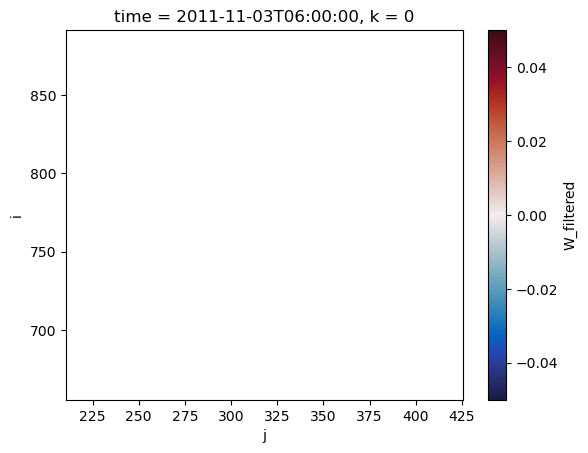

In [24]:
plt.close()
w_filt['W_filtered'].isel(time=9).where(np.isfinite(lcs_land_mask)).plot(cmap=cmocean.cm.balance)


In [11]:
len(current_panels)

486

In [ ]:
#do pl64 animation next
for i in tqdm(range(0,400)):
    FTLE_threshold = [1e-6,5e-5]
    FTLE_threshold_r = [-8e-5,0]#repelling
    fig,ax = plt.subplots(ncols=3, nrows=3,figsize=(24,16))
    vor_div_lcs['divergence'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,0])
    vor_div_lcs['vorticity'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0,1])
    vor_div_lcs['ALCS'].isel(time=i).plot(vmin=FTLE_threshold[0],vmax=FTLE_threshold[1],ax=ax[1,0])
    vor_div_lcs['RLCS'].isel(time=i).plot(vmin=FTLE_threshold_r[0],vmax=FTLE_threshold_r[1],ax=ax[1,1])
    w_filt['W_filtered'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(vmin=-3e-6,vmax=3e-6,ax=ax[0,2],cmap=cmocean.cm.balance)
    salt_temp_w['Theta'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(ax=ax[1,2],vmin=9,vmax=17,cmap=cmocean.cm.thermal)
    salt_temp_w['Salt'].isel(time=i).where(np.isfinite(lcs_land_mask)).plot(ax=ax[2,2],vmin=31,vmax=34,cmap=cmocean.cm.haline)
    lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures']
    lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures']
    lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures']
    ax[2,0].plot(lon_points_attr,lat_points_attr,'r.',markersize=1)
    ax[2,1].plot(lon_points_rep,lat_points_rep,'r.',markersize=1)
    ax[2,1].set_xlim([-128,-123])
    ax[2,0].set_xlim([-128,-123])
    ax[2,1].set_ylim([38.5,42])
    ax[2,0].set_ylim([38.5,42])
    ax[2,0].set_xlabel('lon')
    ax[2,0].set_ylabel('lat')
    ax[2,1].set_xlabel('lon')
    ax[2,1].set_ylabel('lat')
    ax[2,1].set_title('extracted repelling ridges')
    ax[2,0].set_title('extracted attracting ridges')
    plt.tight_layout()
    plt.savefig('/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/vort_lcs_div/vort_lcs_div_'+str(i).zfill(4)+'.png')
    plt.close()

  0%|          | 0/1519 [00:00<?, ?it/s]

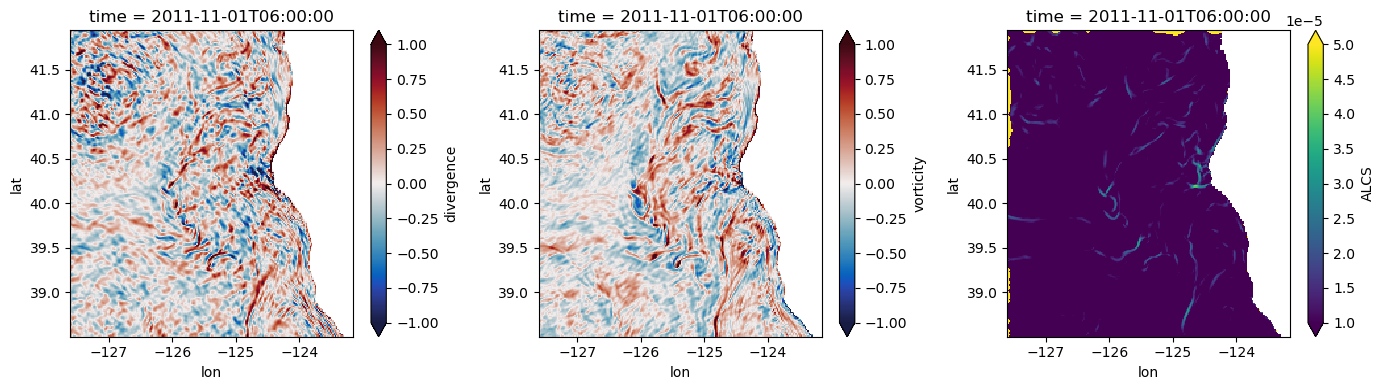

In [74]:
FTLE_threshold = [1e-5,5e-5] #Attracting
i=1
fig,ax = plt.subplots(ncols=3, nrows=1,figsize=(14,4))
vor_div_lcs['divergence'].isel(time=int(6*i)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[0])
vor_div_lcs['vorticity'].isel(time=int(6*i)).plot(vmin=-1,vmax=1,cmap=cmocean.cm.balance,ax=ax[1])
vor_div_lcs['ALCS'].isel(time=i*6).plot(vmin=FTLE_threshold[0],vmax=FTLE_threshold[1],ax=ax[2])
plt.tight_layout()

In [ ]:
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/basil/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']